# Notebook 03: Drug–Target Interaction Analysis

## AI-Based Identification of Novel Drug Targets for Depression

### Overview

This notebook focuses on analysing known drug–target interactions associated
with proteins linked to depression.

The aim is to prepare a high-quality dataset that can be used for machine
learning by cleaning the interaction data, calculating binding affinity scores,
creating activity labels, and generating molecular fingerprints from drug
structures.

The processed dataset produced in this notebook will serve as the main training
dataset for the machine learning models developed in the later stages of this
project.


### Research Workflow

This notebook represents the third stage of the computational workflow:

1. Analyse known drug–target interactions.
2. Assess the quality and completeness of the interaction data.
3. Standardise binding affinity measurements.
4. Generate activity labels and molecular fingerprints.
5. Prepare the processed dataset for machine learning.


### Dataset Description

The dataset used in this notebook is:

`drug_target_interactions.csv`

This dataset contains experimentally reported interactions between drugs and
proteins, including the drug name, protein identifier, chemical structure,
binding measurement type, binding value, and measurement units.


### Objectives

The main objectives of this notebook are:

1. To explore and understand the drug–target interaction dataset.
2. To clean and standardise the interaction records.
3. To calculate pChEMBL scores from binding affinity values.
4. To classify drug–target interactions as active or inactive.
5. To generate molecular fingerprints for downstream machine learning.

In [41]:
# Install RDKit (Run once per Colab session)

!pip -q install rdkit

In [42]:
# 1. Import Required Libraries

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import AllChem

from IPython.display import display

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [43]:
# 2. Set Up Project Directories

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
PROJECT_ROOT = (
    "/content/drive/MyDrive/Dissertation/"
    "Depression-Drug-Target-AI"
)

RAW_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw"
)

PROCESSED_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)

FIGURE_PATH = os.path.join(
    PROJECT_ROOT,
    "figures"
)

print("Project directories configured successfully.")

Project directories configured successfully.


In [45]:
# 3. Load Drug–Target Interaction Dataset

interaction_file = os.path.join(
    RAW_DATA_PATH,
    "drug_target_interactions.csv"
)

interactions_df = pd.read_csv(interaction_file)

print("Drug-target interaction dataset loaded successfully.")

print(f"Number of interaction records: {interactions_df.shape[0]}")
print(f"Number of features: {interactions_df.shape[1]}")

Drug-target interaction dataset loaded successfully.
Number of interaction records: 4164
Number of features: 9


In [46]:
# 4. Explore Dataset Preview

display(interactions_df.head())

,uniprot_id,target_chembl_id,drug_chembl_id,drug_name,smiles,standard_type,standard_value,standard_units,assay_type
0,P31645,CHEMBL228,CHEMBL322923,NaN,COC(=O)C1=C(c2ccc(Cl)c(Cl)c2)CC2CCC1C2,IC50,5160.00,nM,B
1,P31645,CHEMBL228,CHEMBL435341,NaN,C/C=C\c1ccc([C@H]2CC3CCC([C@H]2C(=O)OC)N3C)cc1,IC50,1.15,nM,B
2,P31645,CHEMBL228,CHEMBL311347,NaN,COC(=O)[C@@H]1C2CC[C@H](C[C@@H]1c1ccc(I)cc1)N2C,Ki,0.67,nM,B
3,P31645,CHEMBL228,CHEMBL311347,NaN,COC(=O)[C@@H]1C2CC[C@H](C[C@@H]1c1ccc(I)cc1)N2C,IC50,4.20,nM,B
4,P31645,CHEMBL228,CHEMBL100941,NaN,COC(=O)C1C2CCC(C2)CC1c1ccc(Cl)c(Cl)c1,IC50,33.40,nM,B


In [47]:
# 5. Understand Dataset Structure

interactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4164 entries, 0 to 4163
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uniprot_id        4164 non-null   object 
 1   target_chembl_id  4164 non-null   object 
 2   drug_chembl_id    4164 non-null   object 
 3   drug_name         500 non-null    object 
 4   smiles            4161 non-null   object 
 5   standard_type     4164 non-null   object 
 6   standard_value    4040 non-null   float64
 7   standard_units    4095 non-null   object 
 8   assay_type        4164 non-null   object 
dtypes: float64(1), object(8)
memory usage: 292.9+ KB


In [48]:
# 6. Generate Statistical Summary

interactions_df.describe(include="all")

,uniprot_id,target_chembl_id,drug_chembl_id,drug_name,smiles,standard_type,standard_value,standard_units,assay_type
count,4164,4164,4164,500,4161,4164,4.040000e+03,4095,4164
unique,51,47,2637,202,2635,4,NaN,1,4
top,P31645,CHEMBL2093872,CHEMBL29846,SUMATRIPTAN,COc1ccc(NS(=O)(=O)c2sc3ccc(Cl)cc3c2C)cc1N1CCN(...,Ki,NaN,nM,B
freq,100,400,14,12,14,2234,NaN,4095,3851
mean,NaN,NaN,NaN,NaN,NaN,NaN,1.526786e+14,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,8.040524e+15,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e-04,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.792500e+01,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3.242950e+02,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5.312500e+03,NaN,NaN


In [49]:
# 7. Assess Data Quality

missing_values = (
    interactions_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values

,0
drug_name,3664
standard_value,124
standard_units,69
smiles,3
uniprot_id,0
target_chembl_id,0
drug_chembl_id,0
standard_type,0
assay_type,0


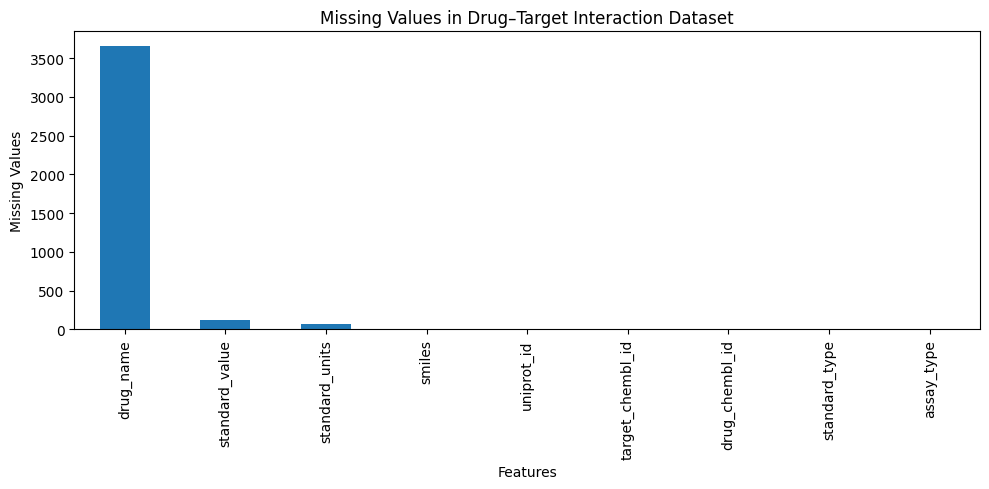

In [50]:
# 8. Analyse Missing Drug–Target Interaction Values

plt.figure(figsize=(10,5))

missing_values.plot(kind="bar")

plt.title("Missing Values in Drug–Target Interaction Dataset")

plt.xlabel("Features")

plt.ylabel("Missing Values")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "interaction_missing_values.png"
    ),
    dpi=300
)

plt.show()

In [51]:
# 9. Check Duplicate Drug–Target Records

duplicates = interactions_df.duplicated().sum()

print(f"Duplicate records: {duplicates}")

Duplicate records: 55


In [52]:
# 10. Explore Binding Measurement Types

interactions_df["standard_type"].value_counts()

,count
standard_type,
Ki,2234
IC50,1517
EC50,354
Kd,59


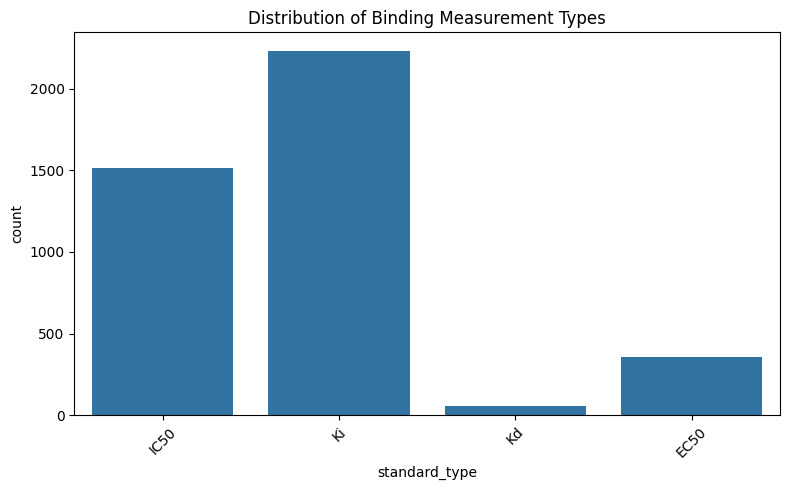

In [53]:
# Visualisation

plt.figure(figsize=(8,5))

sns.countplot(
    data=interactions_df,
    x="standard_type"
)

plt.xticks(rotation=45)

plt.title("Distribution of Binding Measurement Types")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "binding_measurement_types.png"
    ),
    dpi=300
)

plt.show()

In [54]:
# 11. Filter Interactions Measured in nM

clean_df = interactions_df.copy()

clean_df = clean_df[
    clean_df["standard_units"] == "nM"
]

clean_df = clean_df.dropna(
    subset=[
        "smiles",
        "standard_value"
    ]
)

clean_df = clean_df.drop_duplicates(
    subset=[
        "uniprot_id",
        "smiles"
    ]
)

print(f"Remaining records: {len(clean_df)}")

Remaining records: 3590


In [55]:
# 12. Calculate pChEMBL Scores

clean_df["pchembl"] = -np.log10(
    clean_df["standard_value"] * 1e-9
)

display(
    clean_df[
        [
            "drug_name",
            "standard_value",
            "pchembl"
        ]
    ].head()
)

,drug_name,standard_value,pchembl
0,NaN,5160.00,5.287350
1,NaN,1.15,8.939302
2,NaN,0.67,9.173925
4,NaN,33.40,7.476254
5,NaN,0.05,10.301030


In [56]:
# 13. Create Drug Activity Labels

clean_df["active"] = (
    clean_df["pchembl"] >= 6
).astype(int)

print(
    clean_df["active"].value_counts()
)

active
1    2172
0    1418
Name: count, dtype: int64


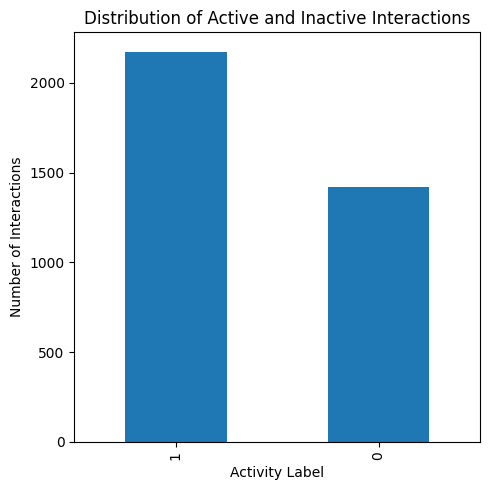

In [57]:
# Visualisation

plt.figure(figsize=(5,5))

clean_df["active"].value_counts().plot(kind="bar")

plt.title("Distribution of Active and Inactive Interactions")

plt.xlabel("Activity Label")

plt.ylabel("Number of Interactions")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "activity_label_distribution.png"
    ),
    dpi=300
)

plt.show()

In [58]:
# 14. Generate Morgan Fingerprints

def smiles_to_fp(smiles):

    molecule = Chem.MolFromSmiles(smiles)

    if molecule is None:
        return None

    return list(
        AllChem.GetMorganFingerprintAsBitVect(
            molecule,
            radius=2,
            nBits=1024
        )
    )

clean_df["fingerprint"] = (
    clean_df["smiles"]
    .apply(smiles_to_fp)
)

clean_df = clean_df.dropna(
    subset=["fingerprint"]
)

print("Morgan fingerprints generated successfully.")

[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerator
[12:05:59] DEPRECATION WARNING: please use MorganGenerat

Morgan fingerprints generated successfully.


[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerator
[12:06:01] DEPRECATION WARNING: please use MorganGenerat

In [59]:
print(clean_df[["drug_name", "fingerprint"]].head())

print(type(clean_df["fingerprint"].iloc[0]))

print(len(clean_df["fingerprint"].iloc[0]))

  drug_name                                        fingerprint
0       NaN  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1       NaN  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2       NaN  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4       NaN  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
5       NaN  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...
<class 'list'>
1024


In [60]:
# 15. Save Processed Interaction Data

processed_interactions = os.path.join(
    PROCESSED_DATA_PATH,
    "clean_drug_target_interactions.pkl"
)

clean_df.to_pickle(
    processed_interactions
)

print("Processed interaction dataset saved successfully.")

Processed interaction dataset saved successfully.


In [61]:
# 16. Download Processed Files

from google.colab import files

files.download(processed_interactions)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary of Findings

This notebook analysed the drug–target interaction dataset and prepared it for
machine learning.

The interaction records were cleaned by removing incomplete entries, filtering
measurements reported in nanomolar (nM), and removing duplicate drug–protein
pairs. Binding affinity values were converted to pChEMBL scores, and each
interaction was labelled as active or inactive based on the calculated score.

Molecular fingerprints were generated from the drug SMILES structures to create
numerical representations that can be used as input features for machine
learning models.

The processed interaction dataset produced in this notebook will be used in the
next stage of the project to develop predictive models for identifying potential
drug–target interactions associated with depression.